In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('Dataset/db_deteccao_cilindro.csv',sep=';')

df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

# 1. Filtra os nomes apenas das colunas que estão como texto (object ou string)
colunas_texto = df.select_dtypes(include=['object', 'string']).columns

# 2. Passa por cada uma dessas colunas limpando e convertendo
for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

display(df.info())
display(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Média      1000 non-null   float64
 1   Variância  1000 non-null   float64
 2   Máximo     1000 non-null   float64
 3   Energia    1000 non-null   float64
 4   Skewness   1000 non-null   float64
 5   Kurtosis   1000 non-null   float64
 6   Label      1000 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 54.8 KB


None

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
0,-8.118985e+15,5.046065e+15,4.260445e+15,1.953800e+16,-1.530590e+15,8.882906e+15,1
1,-7.001265e+15,2.914391e+16,3.199970e+15,1.132615e+16,-1.704711e+15,5.186916e+15,1
2,-8.304564e+15,4.730422e+15,4.120398e+15,1.834326e+15,6.256202e+14,6.203662e+15,1
3,-6.039109e+15,3.363005e+15,3.598051e+15,1.299280e+16,5.076175e+15,7.962693e+14,1
4,-4.586327e+15,2.934315e+16,3.229173e+15,1.129535e+16,7.629875e+15,6.374970e+15,1
5,-8.532184e+15,2.362211e+14,4.549830e+15,9.306606e+14,-1.893496e+14,1.054297e+15,0
6,-7.259698e+15,2.023632e+16,2.628168e+15,7.935753e+15,-4.793369e+15,4.334523e+15,1
7,-8.960045e+15,1.477602e+16,2.488390e+15,5.954233e+15,-1.875898e+15,7.132227e+15,0
8,-8.768693e+15,1.411963e+15,3.092988e+15,5.690397e+15,-2.274281e+16,9.322592e+13,0
9,-7.678424e+15,2.631594e+15,3.851583e+15,1.028329e+16,-5.137717e+15,8.987994e+15,1


A acurácia do modelo Gaussian-Naive-Bayes foi de 66.33%


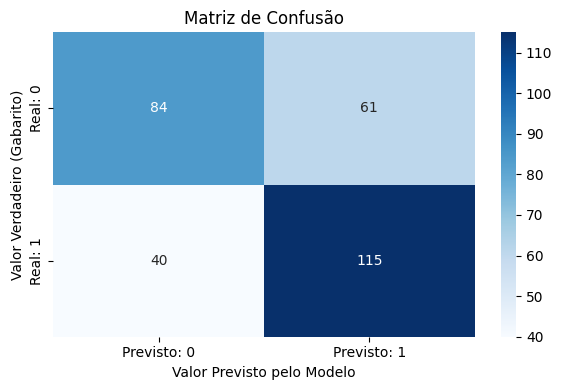

In [17]:
Y = df['Label']
X = df.drop(columns=['Label'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

modelo = GaussianNB()

modelo.fit(X_train,y_train)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Gaussian-Naive-Bayes foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
# annot=True mostra os números, fmt='d' garante que sejam inteiros
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

USAR ESSA PARA VISUALIZAÇÃO

PEDIR IA ÁRA FAZER VISUALIZAÇÃO DOS SLIDES

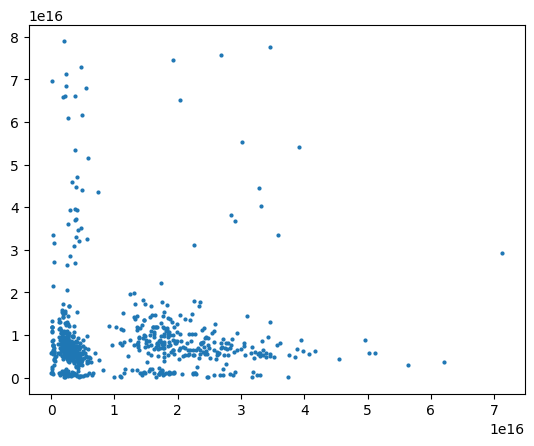

In [24]:
X_plot = np.array(X_train)

plt.figure()

plt.plot(X_plot[:,1],X_plot[:,-1],'o',markersize='2')

plt.show()